In [1]:
import json
import numpy as np
import pandas as pd
from scipy import stats
from matplotlib import pyplot as plt

In [2]:
datasets = {
    "fashion": {},
    "mnist": {},
    "kmnist": {}
}

for name, data in datasets.items():
    with open(f"./whole/tests/GA/{name}/results_AE.json", "r") as file:
        AE = json.load(file) # list of dictionaries
        data["AE"] = AE

    with open(f"./whole/tests/GA/{name}/results_noAE.json", "r") as file:
        noAE = json.load(file) # list of dictionaries
        data["noAE"] = noAE

In [3]:
fashion = datasets["fashion"]
for key, value in fashion.items():
    print(key, value)

AE [{'dataset': 'fashion', 'pop_size': 15, 'runs': 32, 'gens': 21, 'exp_condition': True, 'seed': 34, 'subset_fraction': 0.07, 'decay': True, 'm_r_min': 0.01, 'm_r_max': 0.3, 'm_strength': 0.2, 'm_mode': 'light'}, {'fit_in_time': [0.11169840395450592, 0.11876190453767776, 0.13049206137657166, 0.14450792968273163, 0.15380951762199402, 0.15895238518714905, 0.16304761171340942, 0.17099998891353607, 0.17493648827075958, 0.1777460277080536, 0.1827142834663391, 0.18365079164505005, 0.18555554747581482, 0.18615871667861938, 0.19173015654087067, 0.1995396912097931, 0.19960317015647888, 0.20112697780132294, 0.20739680528640747, 0.2209523767232895, 0.23236507177352905], 'test_fit': 0.21895238095238095}, {'fit_in_time': [0.12903174757957458, 0.13541269302368164, 0.1435396820306778, 0.14998413622379303, 0.15268254280090332, 0.15696826577186584, 0.16336508095264435, 0.16496826708316803, 0.1702222228050232, 0.17653967440128326, 0.18044444918632507, 0.18542858958244324, 0.1946825385093689, 0.20328572

In [4]:
def fetch_dv(results:dict, what:str):
    """return either list if what="fit_in_time" or int if what="test_fit" """
    return results[what] # results.get(what)

In [5]:
summary = {
    "fashion": {"AE": None, "noAE": None}, # gonna be list of two lists 
    "mnist": {"AE": None, "noAE": None},
    "kmnist": {"AE": None, "noAE": None}
}

for name, results in datasets.items():
    AE_runs = results["AE"][1:]
    noAE_runs = results["noAE"][1:]
    AE = np.array([fetch_dv(run, "test_fit") for run in AE_runs]) #first results element = exp.details
    noAE = np.array([fetch_dv(run, "test_fit") for run in noAE_runs])
    summary[name]["AE"] = AE
    summary[name]["noAE"] = noAE


print(summary["kmnist"]["AE"])

[0.14419048 0.15361905 0.14590476 0.17295238 0.12866667 0.18019048
 0.16219048 0.16857143 0.182      0.14619048 0.18952381 0.18533333
 0.16028571 0.17952381 0.18       0.18952381 0.14314286 0.16019048
 0.15809524 0.20104762 0.16866667 0.15142857 0.20238095 0.16
 0.15838095 0.17495238 0.16504762 0.15580952 0.17438095 0.184
 0.20019048 0.14447619]


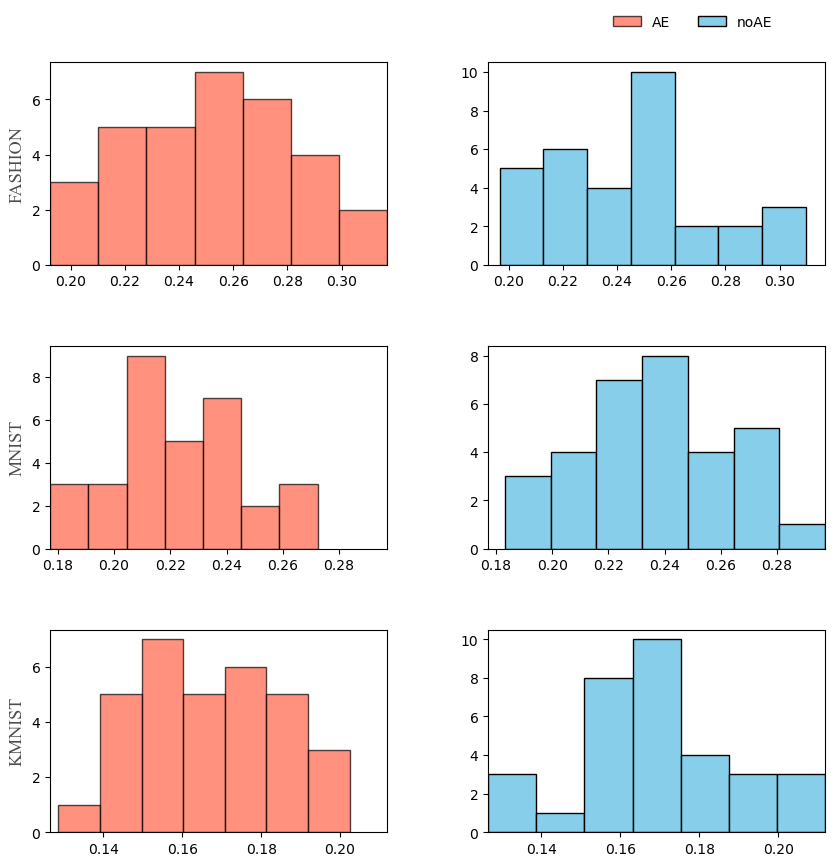

In [6]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 10)) 

colours = {"AE": "tomato", "noAE": "skyblue"}

for i, (key, value) in enumerate(summary.items()):
    # print(value["AE"], value["noAE"])
    xmin = min(value["AE"].min(), value["noAE"].min())
    xmax = max(value["AE"].max(), value["noAE"].max())

    axes[i, 0].hist(value["AE"], bins=7, color=colours["AE"], edgecolor="black", alpha=0.7)
    axes[i, 0].set_xlim(xmin, xmax)
    axes[i, 0].set_ylabel(key.upper(), fontsize=13, fontname="Times New Roman", alpha=0.7)

    axes[i, 1].hist(value["noAE"], bins=7, color=colours["noAE"], edgecolor="black")
    axes[i, 1].set_xlim(xmin, xmax)

# fig.suptitle(
#     "Avg. Test Accuracy per Condition",
#     fontsize=20,
#     fontname="Times New Roman",
#     fontweight="bold"
# )

fig.legend(
    ["AE", "noAE"],
    loc="upper right",
    ncol=2, fontsize=10,
    frameon=False,
    bbox_to_anchor=(0.86, 0.94)
)
fig.subplots_adjust(top=0.88, hspace=0.4, wspace=0.3)

fig.savefig("./whole/tests/GA/histo_7bins.png", dpi=300, bbox_inches="tight")

In [77]:
with open("./whole/tests/GA/results.txt", "w") as f:
    for key, value in summary.items():

        avg_AE = np.mean(value["AE"])
        std_AE = np.std(value["AE"])
        avg_noAE = np.mean(value["noAE"])
        std_noAE = np.std(value["noAE"])
        
        t_test = stats.ttest_ind(value["AE"], value["noAE"], equal_var=True) # scipy.stats.mannwhitneyu ????
        u_test = stats.mannwhitneyu(value["AE"], value["noAE"], alternative="two-sided")
        
        p_value_t = t_test[1]
        p_value_u = u_test.pvalue

        testo = f"""
            * {key} dataset:
                
                AE condition:
                    mean = {round(avg_AE, 4)} , std = {round(std_AE, 4)}
                
                noAE condition:
                    mean = {round(avg_noAE, 4)} , std = {round(std_noAE, 4)}
                
                p-value (two-tailed Student's t-test) = {round(p_value_t, 4)}
                p-value (two-tailed Mann-Whitney) = {round(p_value_u, 4)}
            """
        
        print(testo)

        f.write(testo)


            * fashion dataset:

                AE condition:
                    mean = 0.2519 , std = 0.0307

                noAE condition:
                    mean = 0.2454 , std = 0.0302

                p-value (two-tailed Student's t-test) = 0.4
                p-value (two-tailed Mann-Whitney) = 0.3976
            

            * mnist dataset:

                AE condition:
                    mean = 0.2224 , std = 0.0238

                noAE condition:
                    mean = 0.2355 , std = 0.0267

                p-value (two-tailed Student's t-test) = 0.0455
                p-value (two-tailed Mann-Whitney) = 0.0566
            

            * kmnist dataset:

                AE condition:
                    mean = 0.1678 , std = 0.0184

                noAE condition:
                    mean = 0.1686 , std = 0.0207

                p-value (two-tailed Student's t-test) = 0.8765
                p-value (two-tailed Mann-Whitney) = 0.9358
            


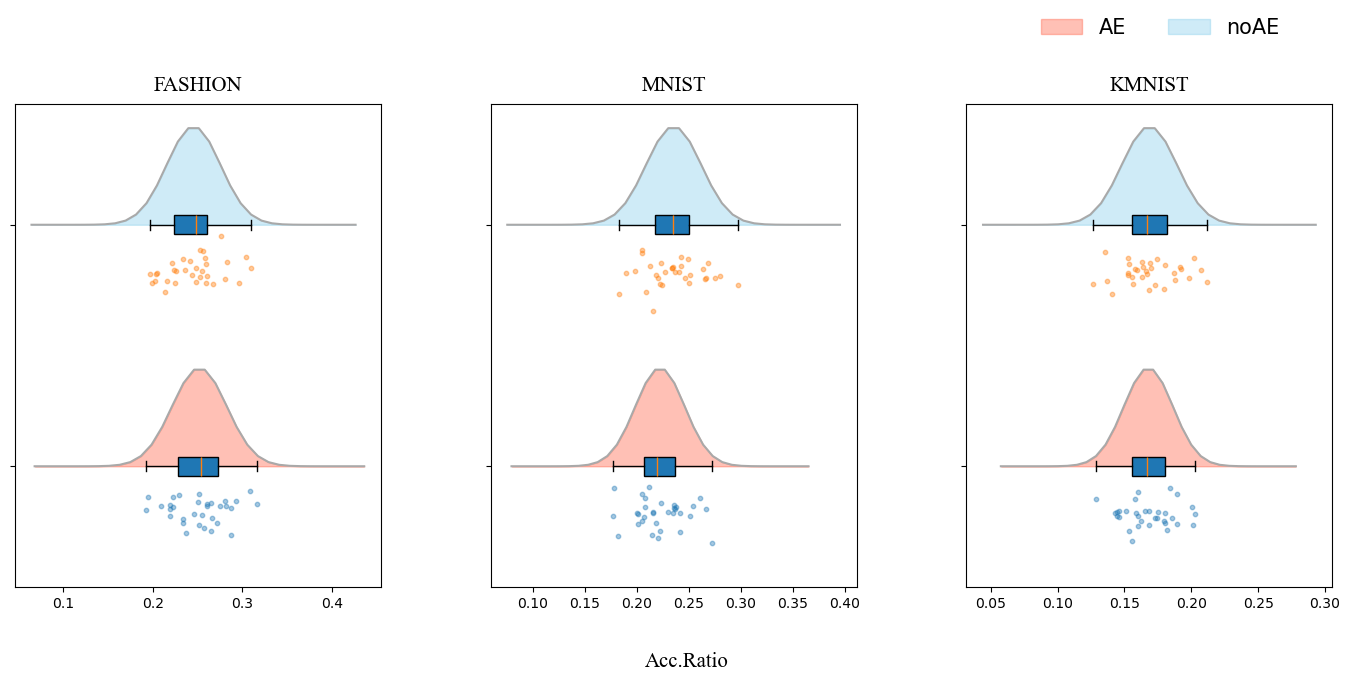

In [73]:
assume_normal = True

fig, ax = plt.subplots(nrows=1, ncols=3, figsize =(17, 7))

for col, (dataset, results) in enumerate(summary.items()):
    for i, (condition, dv) in enumerate(results.items()):
        label = condition if col == 0 else None

        if assume_normal:
            mean = dv.mean()
            std = dv.std()
            x = np.linspace(mean - 6*std, mean + 6*std, len(dv))
            y = stats.norm.pdf(x, mean, std)
        else:
            # add density function (both fill up and delimiting lines?)
            kde = stats.gaussian_kde(dv)
            x = np.linspace(min(dv)-1, max(dv)+1, num=len(dv))
            y = kde(x)
        
        y = y / y.max() * 0.4 

        color = "tomato" if condition=="AE" else "skyblue"
        ax[col].fill_between(x, i, y + i,
                             alpha=0.4,
                             color=color,
                             label=label) # space between base and top of cloud
        ax[col].plot(x, y + i, color="darkgrey")
        
        # add boxplot
        ax[col].boxplot(dv,
                vert=False,
                positions=[i],
                widths=0.08,
                patch_artist=True,
                showfliers=True) # show outliers!!!

        # add raindrops (scatter)
        jitter = np.random.normal(loc=0, scale=0.05, size=len(dv))
        ax[col].scatter(x=dv,
                y=i - 0.2 + jitter,
                alpha=0.4,
                s=10)
        
        ax[col].set_title(dataset.upper(), fontsize=15, fontname="Times New Roman", pad=10)
        # ax[col].xaxis.set_label_coords(0.85, -0.15)
        ax[col].set_yticklabels([])

fig.supxlabel("Acc.Ratio", fontsize=15, fontname="Times New Roman", y=-0.01, x=0.52)
# fig.suptitle(
#     "Avg. Test Accuracy per Condition",
#     fontname="Times New Roman",
#     fontsize=30,
#     fontweight="bold"
# )

fig.legend(
    # ["AE", "noAE"],
    loc="upper right",
    ncol=2, fontsize=15,
    frameon=False,
    bbox_to_anchor=(0.88, 0.95)
)
fig.subplots_adjust(top=0.8, hspace=0.4, wspace=0.3)
fig.savefig("./whole/tests/GA/rainclouds.png", dpi=300, bbox_inches="tight")

# plt.tight_layout()
plt.show()

In [38]:
curves = {
    "fashion": {"AE": None, "noAE": None}, # gonna be list of two lists 
    "mnist": {"AE": None, "noAE": None},
    "kmnist": {"AE": None, "noAE": None}
}

for name, results in datasets.items():
    AE_runs = results["AE"][1:]
    noAE_runs = results["noAE"][1:]
    AE = [fetch_dv(run, "fit_in_time") for run in AE_runs] #first results element = exp.details
    noAE = [fetch_dv(run, "fit_in_time") for run in noAE_runs]
    curves[name]["AE"] = AE
    curves[name]["noAE"] = noAE

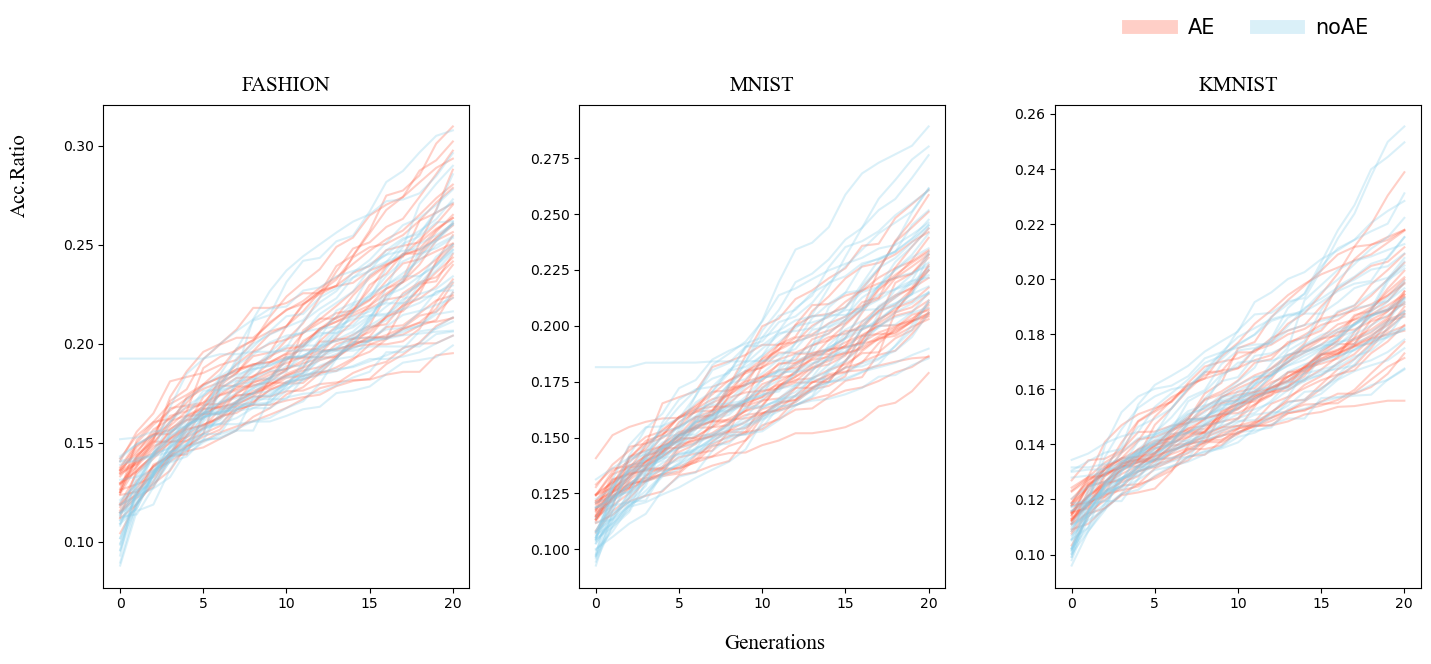

In [75]:
from matplotlib.lines import Line2D

handles = [
    Line2D([0], [0], color="tomato", lw=10, alpha=0.3, label="AE"),
    Line2D([0], [0], color="skyblue", lw=10, alpha=0.3, label="noAE")
]

fig, ax = plt.subplots(nrows=1, ncols=3, figsize =(17, 7))

for col, (dataset, results) in enumerate(curves.items()):
    for condition, dv in results.items():
        label = condition if col == 0 else None
        for gen in dv:
            colour = "tomato" if condition=="AE" else "skyblue"
            ax[col].plot(gen, alpha=0.3, color=colour, label=label)
    
    ax[col].set_title(dataset.upper(), fontsize=15, fontname="Times New Roman", pad=10)

fig.legend(
    handles=handles, 
    loc="upper right",
    ncol=2, fontsize=15,
    frameon=False,
    bbox_to_anchor=(0.88, 0.95))

fig.supxlabel("Generations", fontsize=15, fontname="Times New Roman", y=0.015, x=0.52)
fig.supylabel("Acc.Ratio", fontsize=15, fontname="Times New Roman", y=0.7, x=0.07)
# fig.suptitle("Avg. Accuracy in Time", fontsize=30, fontname="times New Roman")
fig.subplots_adjust(top=0.8, hspace=0.4, wspace=0.3)

fig.savefig("./whole/tests/GA/fitintime.png", dpi=300, bbox_inches="tight")
